<a href="https://colab.research.google.com/github/Odeyiany2/ACCESS-6.0-Skills-Acquisition-Program-Data-Science/blob/main/week%206/Week_6_Session_11_Model_Evaluation_and_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Model Evaluation and Tuning**

In the last session, we:
- Built our first regression model (Linear Regression)
- Learned how preprocessing, scaling, and encoding fit into a pipeline
- Evaluated model performance using RMSE and MAE

In this session, we will:
- Train and compare multiple models
- Understand why different models give different results
- Learn how to evaluate models more reliably
- Introduce hyperparameter tuning
- Avoid overfitting


In [1]:
#imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#getting the dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/budgetwise_cleaned.csv')
df.head() # Display the first few rows

Mounted at /content/drive


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,year,month,month_name,day_of_week,quarter,spending_level,is_high_value,is_weekend,total_user_spending,avg_user_transaction
0,T4999,U018,2023-04-25,Expense,education,3888,card,ahmedabad,2023,4,April,Tuesday,2,Medium,False,False,759875,8259.510870
1,T12828,U133,2021-12-16,Expense,rent,649,Unknown,hyderabad,2021,12,December,Thursday,4,Small,False,False,998527,12030.445783
2,T7403,U091,2021-12-16,Income,freelance,13239,Csh,bangalore,2021,12,December,Thursday,4,Large,True,False,1127019,11500.193878
3,T7495,U088,2021-12-16,Expense,entertainment,2287,CARD,hyderabad,2021,12,December,Thursday,4,Medium,False,False,1144448,12439.652174
4,T12465,U042,2021-12-16,Expense,food,4168,Unknown,not specified,2021,12,December,Thursday,4,Medium,False,False,1015065,11803.081395


### **Reminder: Data Setup**

We are using the same dataset and preprocessing from Session 9.

- X → features
- y → target variable
- preprocessor → ColumnTransformer with:
  - Scaling for numeric columns
  - Encoding for categorical columns


In [3]:
#defining X and y
y = df["amount"] #target variable
X = df.drop(columns = ["amount", "transaction_id", "user_id", "date"], axis = 1) #features

In [4]:
#splitting the columns
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(include = ["float64", "int64"]).columns


categorical_features, numerical_features

(Index(['transaction_type', 'category', 'payment_mode', 'location',
        'month_name', 'day_of_week', 'spending_level'],
       dtype='object'),
 Index(['year', 'month', 'quarter', 'total_user_spending',
        'avg_user_transaction'],
       dtype='object'))

In [5]:
#scaling
scale = StandardScaler()
encoder = OneHotEncoder(handle_unknown = "ignore")


#column transformer
preprocessor = ColumnTransformer(
    transformers = [
        ("num", scale, numerical_features),
        ("cat", encoder, categorical_features)
    ]
)

In [6]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


### **Models We Will Compare**

1. Linear Regression – simple baseline
2. Decision Tree Regressor – rule-based model
3. Random Forest Regressor – ensemble model (many trees working together)
4. XGBoost


In [7]:
#defining the models
models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("dt_regressor", DecisionTreeRegressor(random_state = 42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("rf_regressor", RandomForestRegressor(random_state = 42))
    ])
}

### **Evaluation with Functions**

To:
- Avoid repeating code
- Compare models fairly
- Focus on results, not syntax


In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
  """
  Evaluate the model on the training and test dataset

  Return:
      The performance of the model: RMSE, MAE, R2 Score

  """

  #train the model
  model.fit(X_train, y_train)

  #make predictions
  y_preds = model.predict(X_test)

  #evalute performance
  mae = mean_absolute_error(y_test, y_preds)
  rmse = np.sqrt(mean_squared_error(y_test, y_preds))
  r2 = r2_score(y_test, y_preds)

  return mae, rmse, r2

### **Training and Model Comparisons**

In [9]:
#training each model

results = []  #used to store the model's result

for model_name, model in models.items():
  #using the function to evaluate each model in the dictionary
  mae, rmse, r2 = evaluate_model(model, X_train, X_test, y_train, y_test)

  #getting the results
  results.append({
      "Model": model_name,
      "MAE": mae,
      "RMSE": rmse,
      "R2_Score": r2
  })

#creating a dataframe for the results

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2_Score
0,Linear Regression,5351.266202,9472.509501,0.700146
1,Decision Tree,6507.738459,13692.930165,0.373427
2,Random Forest,5058.473333,9805.623972,0.678686


In [11]:
#try xgboost
xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb_regressor", XGBRegressor(random_state = 42))
])

#evaluate
mae, rmse, r2 = evaluate_model(xgb, X_train, X_test, y_train, y_test)

#print results
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 5482.90673828125
RMSE: 10422.260023622515
R2 Score: 0.6370030641555786


In [12]:
df.shape

(13755, 18)

### **Visual Comparison of Model Performance**


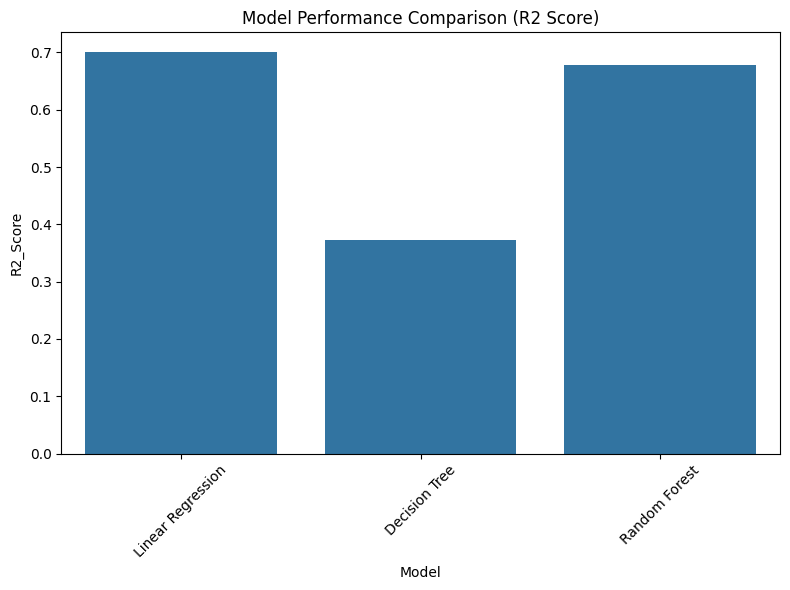

In [13]:
plt.figure(figsize=(8, 6))
sns.barplot(data = results_df, x = "Model", y = "R2_Score")
plt.title("Model Performance Comparison (R2 Score)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show();

### **Cross-Validation**

Instead of trusting a single split:
- We split the data multiple times
- Train and test multiple times
- Get a more reliable estimate of performance


- Linear Regression
- Adaboost
- ExtraTrees
- Decision Tree
- Xgboost

In [14]:
#cross validation
cv_scores = cross_val_score(models["Random Forest"],
                            X,
                            y,
                            scoring = "neg_root_mean_squared_error", cv = 5)

print(f"Average CV RMSE: {-cv_scores.mean()}")

Average CV RMSE: 9672.686222956756


### **Feature Importance (Random Forest)**

Which features influenced predictions the most?


In [18]:
#feature importance
model_rf = models["Random Forest"]
model_rf.fit(X_train, y_train)

feature_names = model_rf.named_steps["preprocessor"].get_feature_names_out()

#get importance score
importances = model_rf.named_steps["rf_regressor"].feature_importances_

Importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by = "importance", ascending = False)

Importance_df.head(10)

,feature,importance
6,cat__transaction_type_Income,0.319131
5,cat__transaction_type_Expense,0.306956
72,cat__spending_level_Large,0.050255
4,num__avg_user_transaction,0.048707
3,num__total_user_spending,0.043149
16,cat__category_rent,0.037375
1,num__month,0.008332
0,num__year,0.007268
49,cat__location_lucknow,0.004920
52,cat__location_pune,0.004773


### **Hyperparameter Tuning**

Hyperparameters control:
- Model complexity
- How the model learns

We tune them to:
- Improve performance
- Reduce overfitting


In [15]:
#parameter define

param_grid = {
    "rf_regressor__n_estimators": [50, 100],
    "rf_regressor__max_depth": [None, 10, 20],
    "rf_regressor__min_samples_split": [2, 5]
}


#grid
grid = GridSearchCV(
    models["Random Forest"],
    param_grid = param_grid,
    scoring = "neg_root_mean_squared_error",
    cv = 3,
    n_jobs = -1
)

#fit to our training dataset
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['year', 'month', 'quarter', 'total_user_spending',
       'avg_user_transaction'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['transaction_type', 'category', 'payment_mode', 'location',
       'month_name', 'day_of_week', 'spending_level'],
      dtype='object'))])),
                                       ('rf_regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf_regressor__max_depth': [None, 10, 20],
                         'rf_regressor__min_samples_split': [2, 5],
                         'rf_regressor__n_estimators': [50, 100]},
             scoring='neg_root_mean_squared_error')

In [16]:
print("Best Parameter:", grid.best_params_)
print("Best CV RMSE Score:", -grid.best_score_)

Best Parameter: {'rf_regressor__max_depth': 10, 'rf_regressor__min_samples_split': 5, 'rf_regressor__n_estimators': 100}
Best CV RMSE Score: 9317.481050268487


## **Stacking Regressors**

combining multiple models together. Then you use a final estimator to combine the predictions from the models together


random, decision, xgboost -> linear regression

In [ ]:
#